## 数据集下载与解压

In [100]:
import hashlib
import os
import tarfile
import zipfile
import requests
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

*dict()* 创建字典

In [101]:
#下载
def download(name, cache_dir=os.path.join('..','data')):
    assert name in DATA_HUB,f"{name}不在{DATA_HUB}中"
    url,sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir,exist_ok=True)
    fname = os.path.join(cache_dir,url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname,'rb') as f:
            while True:
                data = f.read(1024*1024)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname
    print(f"正在从{url}下载{fname}")
    r = requests.get(url, stream=True)
    with open(fname,'wb') as f:
        f.write(r.content)
    return fname

* cache_dir=os.path.join('..','data')
既可以和name一样作为变量传入，也可以使用默认值
```python
os.path.join('..','data') #当前目录的上一级中名为data的文件夹
```
* split('/')[-1]
以'/'作为分割线进行分割
正数索引（0, 1, 2...）是从左往右数 负数索引（-1, -2, -3...）是从右往左数。
* os.makedirs(cache_dir,exist_ok=True)
创建文件夹，*exist_ok=True*表示如果该文件夹已经存在，不会报错
* with open (fname,'rb'/'wb') as:
*r/w* --> 只读/只写，    *b* --> 二进制模式
* r = requests.get(url, stream=True, vertify=Ture)
get --> get请求
stream -->流式请求
vertify -->SSL证书校验
* return fname
返回的是文件地址，不是整个文件内容，不然内存就爆了

In [102]:
#下载、解压缩
def download_extract(name,folder=None):
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname,'r')#File Pointer,文件对象
    elif ext in ('.tar','.gz'):
        fp = tarfile.open(fname,'r')
    else:
        assert False,'文件类型不受支持'
    fp.extractall(base_dir)
    return os.path.join(base_dir,folder) if folder else data_dir
#下载所有文件
def download_all():
    for name in DATA_HUB:
        download_extract(name)

In [103]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [104]:
DATA_HUB['kaggle_house_train'] = (
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

In [105]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

1. download传回的只是文件路径（字符串），
2. pd.read_csv通过文件路径找到该文件，读取并放到内存上，
3. 最后把读到的东西赋值给train_data

In [106]:
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [107]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])
#通过整数索引来定位数据 data.iloc[行索引, 列索引]

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL     65.00000       WD        Normal     208500
1   2          20       RL     80.00000       WD        Normal     181500
2   3          60       RL     68.00000       WD        Normal     223500
3   4          70       RL     60.00000       WD       Abnorml     140000


## 数据预处理
1. 将所有缺失的值替换为相应特征的平均值
2. 将*特征*重新*缩放*成零均值和单位方差-->将所有特征放到一个尺度上

*标准化数据有两个原因：
首先，它方便优化。
其次，因为我们不知道哪些特征是相关的， 所以我们不想让惩罚分配给一个特征的系数比分配给其他任何特征的系数更大。*

*id*对于模型训练来书是没有用的，需要将其从数据集中删除
训练集中的最后一列是是房价，也就是我们最终要预测的标签，不能与输入特征混为一谈，故1:-1，从第2列到倒数第2列。
而测试数据集中本身就没有房价这一栏，从第2列到最后一列
*下面把训练集和测试集的数据拼接在一起进行数据预处理*

In [108]:
all_features = pd.concat((train_data.iloc[:,1:-1],test_data.iloc[:,1:]))#为了把train_data和test_data拼到一起，需要把他们打包成一个元组再传给pd.concat()函数

In [109]:
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index#筛选出值为数值的那一栏的索引

In [110]:
all_features[numeric_features] = all_features[numeric_features].apply(lambda x:(x-x.mean())/x.std())

In [111]:
#标准化之后，所有的均值消失，即均值都为0，接下来需要把缺失值都替换成均值，也就是全都换成0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

In [112]:
#处理离散的非数值类的值，使用独热编码替换他们
all_features = pd.get_dummies(all_features,dummy_na=True)
all_features.shape

(2919, 330)

In [113]:
#从pandas格式中提取出numpy格式，并将其转换为张量用于训练
'''
在新版的 Pandas 中，为了节省内存，get_dummies 默认会生成布尔类型（bool）
而numpy不支持object类型的数据转换，因此需要将true和false用1和0替换
'''
all_features = all_features.replace({True:1,False:0})
n_train = train_data.shape[0]#获取训练集的行数。因为我们之前把训练集和测试集拼在一起处理了，现在需要将他们分开
train_features = torch.tensor(all_features[:n_train].values,dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values,dtype=torch.float32)#values只保留关键值
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1,1),dtype=torch.float32)

* [:n_train]
左闭右开，即右边取不到n_train
***别忘了从0开始计数的，右边取不到n_train但总共正好取的是n_train行***

## 训练
采用带有平方损失的线性模型

In [114]:
loss = nn.MSELoss()#均方差损失函数
in_features = train_features.shape[1]
def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))#为什么是1，因为我最终只需要得到房价这一个输入特征
    return net

* log_rmse
输入参数跑一遍网络，然后用相对误差来评估当前网络的预测精度

***经过优化器优化后，网络的参数是实时更新的，在训练结束之前，所有参数都存在显存里***

In [115]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

In [122]:
def train(net,train_features,train_labels,test_features,test_labels,num_epochs,learning_rate,weight_decay,batch_size):
    train_ls,test_ls = [],[]#记录训练和数据的损失
    train_iter = d2l.load_array((train_features,train_labels),batch_size)#按批次加载打包数据，也就是dataloader的封装
    #使用Adam优化算法，比SGD更聪明，能够自动调整学习率
    optimizer = torch.optim.Adam(net.parameters(),lr=learning_rate,weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X,y in train_iter:
            optimizer.zero_grad()#梯度清零
            l = loss(net(X),y)#计算误差
            l.backward()#通过反向传播计算每个参数的梯度，即哪个参数对与产生误差产生的影响大
            optimizer.step()#根据上一步找出的对误差影响大的参数，微调参数
        train_ls.append(log_rmse(net,train_features,train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net,test_features,test_labels))
    return train_ls,test_ls

## K折交叉验证
当训练数据稀缺时，我们甚至可能无法提供足够的数据来构成一个合适的验证集。 这个问题的一个流行的解决方案是采用K折交叉验证。
这里，原始训练数据被分成K个不重叠的子集。
 然后执行K次模型训练和验证，
 每次在个子集上进行训练， 并在剩余的K-1个子集（在该轮中没有用于训练的子集）上进行验证。
 最后，通过对K次实验的结果取平均来估计训练和验证误差。
 * 通俗来说就是，把一份数据掰成 $K$ 份，每次拿其中的 1 份当“考试卷”（验证集），剩下的 $K-1$ 份当“练习题”（训练集）

In [117]:
def get_k_fold_data(k,i,X,y):
    assert k>1,'k要大于1'
    fold_size = X.shape[0] // k#每一行就是一份数据集，有多少行就是有多少份数据集，再整除k得到一共需要多少折
    X_train,y_train = None,None
    for j in range(k):
        idx = slice(j * fold_size,(j+1) * fold_size)
        X_part, y_part = X[idx,:],y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train,X_part],dim=0)
            y_train = torch.cat([y_train,y_part],dim=0)
    return X_train,y_train,X_valid,y_valid


* slice：这和你之前学的 [start:end] 是一样的效果，只不过写成了函数形式。它精准地定位了当前第 $j$ 块数据的起止范围。
* if j == i:如果当前的块号 $j$ 正好等于我们传入的参数 $i$，说明这一块被选中当**验证集（Validation Set）**了。我们把它单独存起来。
* else:如果 X_train 已经有数据了，我们就用 torch.cat(..., 0) 把当前这一块垂直拼接到之前的训练集后面。

* 在K折交叉验证中训练次后，返回训练和验证误差的平均值

In [118]:
def k_fold(k,X_train,y_train,num_epochs,learning_rate,weight_decay,batch_size):
    train_l_sum, valid_l_sum = 0,0
    for i in range(k):
        data = get_k_fold_data(k,i,X_train,y_train)
        net = get_net()
        train_ls,valid_ls = train(net,*data,num_epochs,learning_rate,weight_decay,batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

折1，训练log rmse0.169719, 验证log rmse0.156207
折2，训练log rmse0.162210, 验证log rmse0.190928
折3，训练log rmse0.163972, 验证log rmse0.168263
折4，训练log rmse0.167643, 验证log rmse0.154409
折5，训练log rmse0.162947, 验证log rmse0.182768
5-折验证: 平均训练log rmse: 0.165298, 平均验证log rmse: 0.170515


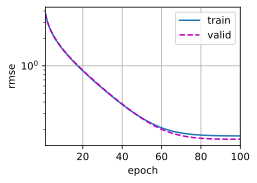

In [123]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

## 为什么要用K折交叉法去找超参数，而不是直接用全部数据
* 这些就是超参数k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
* 给的数据量太少，分成训练集和验证集的话会不够
* 超参数没有经过训练集和验证集的考验，很容易导致过拟合或欠拟合
* ***通过K折交叉验证，选出最强的参数组合***

## 找到最强的超参数后，再去用全部的数据再去训练，即得到了充分的训练，又不会因为参数不合适而过拟合
***这一步是强上加强***

In [124]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.162321


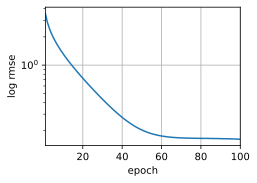

In [125]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)